<a href="https://colab.research.google.com/github/IbtisamSafi/html1/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. استرجاع البيانات (Data Retrieval)
# ملاحظة: تأكد من رفع ملفات train.csv و test.csv إلى Colab أولاً
try:
    train = pd.read_csv('train.csv')
    test = pd.read_csv('test.csv')
    print("تم تحميل البيانات بنجاح!")

    # فحص الأبعاد وأسماء الأعمدة
    print(f"أبعاد بيانات التدريب: {train.shape}")
    print(f"الأعمدة المتاحة: {train.columns.tolist()[:10]}...") # عرض أول 10 أعمدة
except FileNotFoundError:
    print("خطأ: يرجى رفع ملفات train.csv و test.csv إلى مجلد Files في Colab.")

تم تحميل البيانات بنجاح!
أبعاد بيانات التدريب: (1460, 81)
الأعمدة المتاحة: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities']...


In [17]:
# فحص أنواع البيانات والمعلومات العامة
print(train.info())

# تحسين الذاكرة: تحويل المتغيرات النصية المتكررة إلى نوع category
for col in train.select_dtypes(include=['object']):
    if train[col].nunique() < 10:  # إذا كانت القيم الفريدة قليلة
        train[col] = train[col].astype('category')

print("\nتم تحسين الذاكرة بنجاح.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [21]:
# 2. تنظيف البيانات (Data Cleaning)

# أ- معالجة القيم المفقودة بناءً على السياق (لا حذف عشوائي)
# في هذه الأعمدة، NaN تعني عدم وجود الميزة
none_cols = ['PoolQC', 'Alley', 'Fence', 'FireplaceQu', 'MiscFeature']
for col in none_cols:
    if col in train.columns:
        train[col] = train[col].fillna('None')
        test[col] = test[col].fillna('None')

# ب- معالجة الالتواء (Skewness) للمتغير الهدف SalePrice
# نستخدم التحويل اللوغاريتمي لجعله أقرب للتوزيع الطبيعي
if 'SalePrice' in train.columns:
    train['SalePrice'] = np.log1p(train['SalePrice'])
    print("تم تطبيق التحويل اللوغاريتمي على SalePrice.")

تم تطبيق التحويل اللوغاريتمي على SalePrice.


In [22]:
# 3. هندسة الميزات (Feature Engineering)

# أ- الترميز اليدوي للمتغيرات الرتبية (Manual Encoding)
# مثال لترميز الجودة (إذا كانت موجودة)
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
if 'HeatingQC' in train.columns:
    train['HeatingQC'] = train['HeatingQC'].replace(quality_map)

# ب- الميزات التفاعلية (Interaction Terms)
# مثال: ضرب المساحة في الجودة الكلية
if 'GrLivArea' in train.columns and 'OverallQual' in train.columns:
    train['Total_Score'] = train['GrLivArea'] * train['OverallQual']

# ج- الترميز الوهمي (One-Hot Encoding)
train = pd.get_dummies(train)
test = pd.get_dummies(test)

# ضمان تطابق الأعمدة بين التدريب والاختبار بعد الترميز
train_final, test_final = train.align(test, join='left', axis=1)

print("تمت عملية هندسة الميزات والترميز بنجاح.")
print(f"الأبعاد النهائية بعد الترميز: {train_final.shape}")

تمت عملية هندسة الميزات والترميز بنجاح.
الأبعاد النهائية بعد الترميز: (1460, 290)


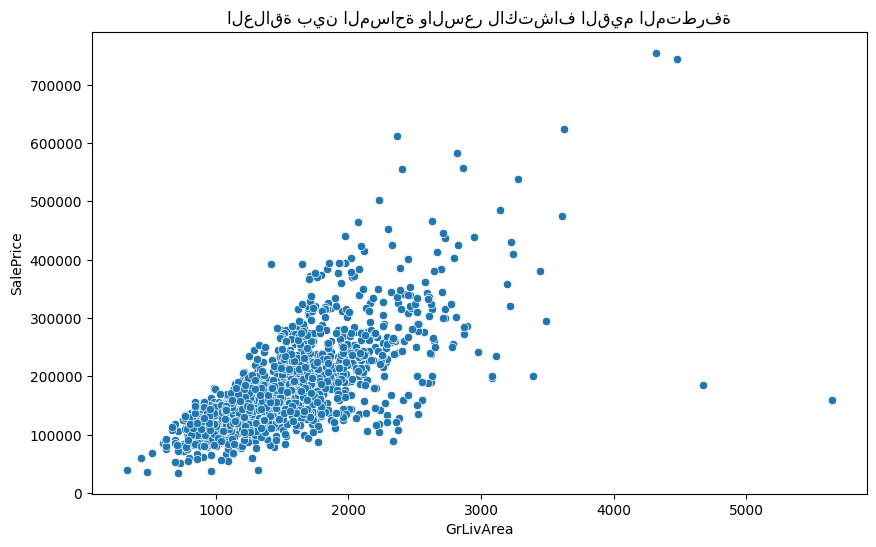

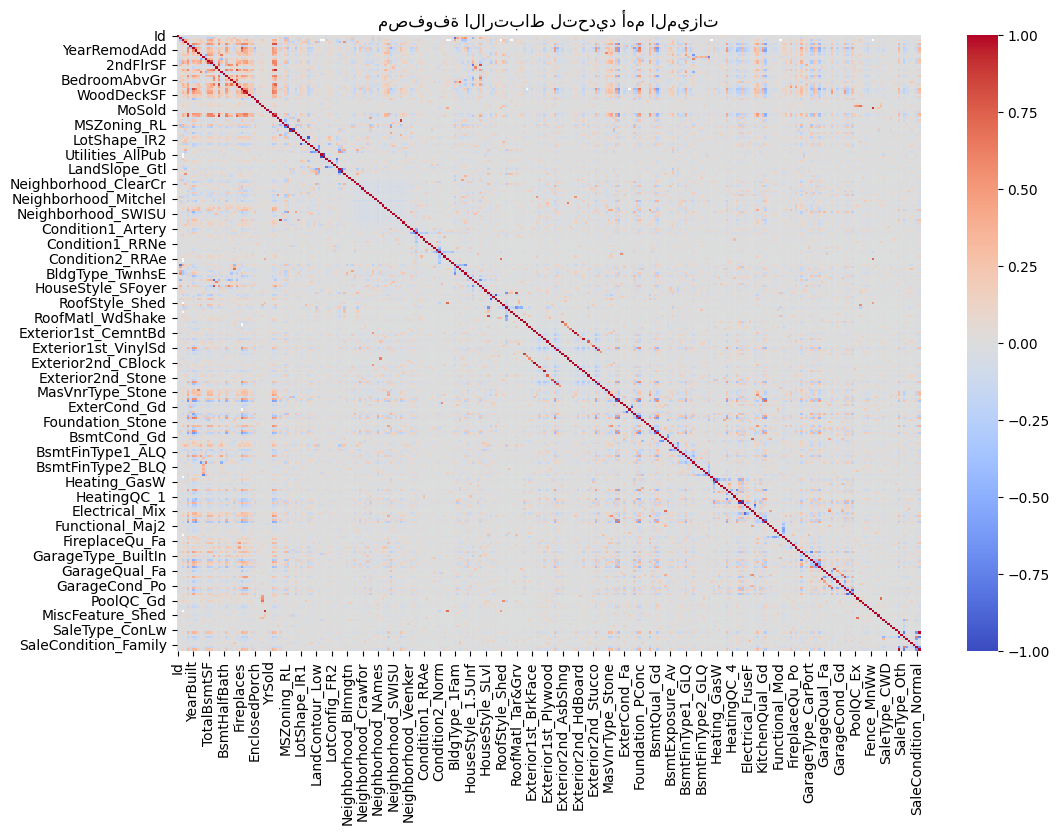

In [20]:
# 4. التحليل البصري (EDA Visuals)

# أ- اكتشاف القيم المتطرفة بصرياً
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.title('العلاقة بين المساحة والسعر لاكتشاف القيم المتطرفة')
plt.show()

# ب- مصفوفة الارتباط (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(train.corr(), annot=False, cmap='coolwarm')
plt.title('مصفوفة الارتباط لتحديد أهم الميزات')
plt.show()